# GeoCalib-Align Colab Notebook

End-to-end Colab workflow for free, open-source fine-tuning and evaluation.

## Section 0: Workspace Setup

This notebook assumes the repository files are already available in Colab, either by cloning the repository into `/content/geocalib_align` or by uploading the project folder.

In [6]:
from pathlib import Path
import os

REPO_URL = os.environ.get("GEOCALIB_ALIGN_REPO_URL", "https://github.com/elom354/geocalib_align.git")
REPO_DIR = Path("/content/GEOCALIB_ALIGN")

if REPO_DIR.exists():
    print("Repo already present at", REPO_DIR)
else:
    !git clone "$REPO_URL" "$REPO_DIR"

%cd /content/GEOCALIB_ALIGN
print("Repo ready at", REPO_DIR)

Repo already present at /content/GEOCALIB_ALIGN
/content/GEOCALIB_ALIGN
Repo ready at /content/GEOCALIB_ALIGN


## Section 1: Environment Setup

Dependencies are installed in a Colab-friendly way without downgrading core system packages such as NumPy, SciPy, Torch, or `fsspec`. This avoids binary incompatibility errors and reduces resolver conflicts with the preloaded Colab stack.

In [7]:
%%time
from pathlib import Path
import importlib.metadata as importlib_metadata
import subprocess
import sys

sentinel = Path('/tmp/geocalib_align_colab_deps_v3')
required = {
    'transformers': '4.46.3',
    'peft': '0.13.2',
    'accelerate': '0.34.2',
    'trl': '0.10.1',
    'bert-score': '0.3.13',
    'kaleido': '0.2.1',
}

def installed_version(dist_name):
    try:
        return importlib_metadata.version(dist_name)
    except importlib_metadata.PackageNotFoundError:
        return None

to_install = []
for dist_name, expected_version in required.items():
    current_version = installed_version(dist_name)
    if current_version != expected_version:
        to_install.append(f'{dist_name}=={expected_version}')

if to_install and not sentinel.exists():
    print({'installing': to_install})
    cmd = [sys.executable, '-m', 'pip', 'install', '-q', '--upgrade-strategy', 'only-if-needed', *to_install]
    subprocess.run(cmd, check=True)
    sentinel.write_text('installed')
    raise SystemExit('Packages were installed. Restart the Colab session manually, then rerun the notebook from the top.')
elif to_install and sentinel.exists():
    raise RuntimeError('Required package versions are still not active after installation. Use Runtime > Factory reset runtime, then rerun from the top.')
else:
    print('Dependency layer is ready.')


Dependency layer is ready.
CPU times: user 8.7 ms, sys: 0 ns, total: 8.7 ms
Wall time: 9.28 ms


In [8]:
import os
from getpass import getpass
import torch

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'
gpu_vram = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2) if torch.cuda.is_available() else 0
print({'gpu_available': torch.cuda.is_available(), 'gpu_name': gpu_name, 'gpu_vram_gb': gpu_vram})
os.environ['HF_TOKEN'] = getpass('Hugging Face token (optional, leave blank for public models): ')

{'gpu_available': True, 'gpu_name': 'Tesla T4', 'gpu_vram_gb': 14.56}
Hugging Face token (optional, leave blank for public models): ··········


## Section 2: Data Loading

GeoBench, EarthSE, and GeoSignal are downloaded automatically by the repository scripts using verified dataset IDs.

{'input': '', 'instruction': 'What can you tell me about the specific gravity of the Manganosegelerite?', 'output': "The Manganosegelerite's specific gravity is 2.76."}
{'input': '"Go beyond your limits"', 'instruction': 'Generate three advertising slogans for the given phrase.', 'output': '1. "Reach new heights with \'Go beyond your limits\'"\n2. "Step out of your comfort zone with \'Go beyond your limits\'"\n3. "Unleash your potential with \'Go beyond your limits\'"'}
{'input': '', 'instruction': 'Which terms in the following passage are considered named entities in geoscience? M. S. Pole comments: In a recent paper Landis et al. (2008) propose that New Zealand was completely submerged in the Late Oligocene–earliest Miocene and therefore, its distinctive terrestrial biota must date from after that time. They propose this based on an analysis of the sedimentological, geomorphological and palaeontological record.', 'output': 'The named entities in the passage related to geoscience are:

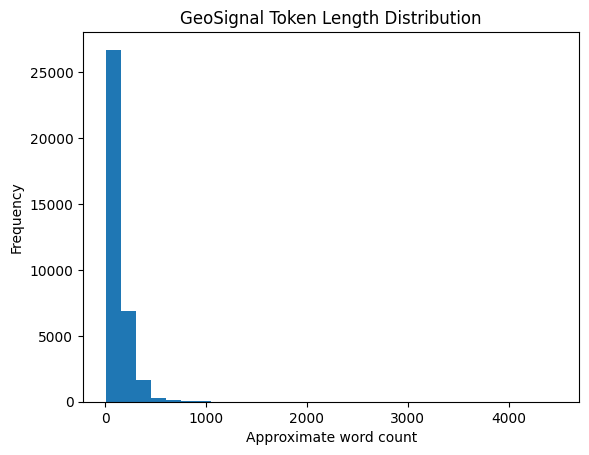

CPU times: user 712 ms, sys: 79.6 ms, total: 792 ms
Wall time: 52 s


In [9]:
%%time
import json
import subprocess
import sys
from pathlib import Path
import matplotlib.pyplot as plt

for script in ['data/download_data.py', 'data/prepare_geosignal.py', 'data/build_physgeo_eval.py']:
    subprocess.run([sys.executable, script], check=True)

train_path = Path('data/processed/geosignal_train.json')
if not train_path.exists():
    raise FileNotFoundError('GeoSignal preparation did not create data/processed/geosignal_train.json')

train_records = json.loads(train_path.read_text())
for sample in train_records[:3]:
    print(sample)

lengths = [len((row['instruction'] + ' ' + row['input'] + ' ' + row['output']).split()) for row in train_records]
plt.hist(lengths, bins=30)
plt.title('GeoSignal Token Length Distribution')
plt.xlabel('Approximate word count')
plt.ylabel('Frequency')
plt.show()


## Section 3: Model Loading

A public non-gated model is used by default so the notebook stays free and does not require special access approval.

## Section 3A: Colab Demo Config

Create a smaller Colab-specific config to keep the demo stable on a free T4 runtime.

In [10]:
import yaml
from pathlib import Path

base_config = Path('config/experiments.yaml')
demo_config = Path('config/experiments_colab_demo.yaml')
cfg = yaml.safe_load(base_config.read_text())
cfg['finetuning']['max_steps'] = 30
cfg['finetuning']['warmup_steps'] = 5
cfg['finetuning']['batch_size'] = 1
cfg['finetuning']['gradient_accumulation'] = 2
cfg['finetuning']['max_seq_length'] = 512
cfg['finetuning']['load_in_4bit'] = False
demo_config.write_text(yaml.safe_dump(cfg, sort_keys=False))
print({'demo_config': str(demo_config)})


{'demo_config': 'config/experiments_colab_demo.yaml'}


In [11]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_id = 'Qwen/Qwen2.5-1.5B-Instruct'
tokenizer = AutoTokenizer.from_pretrained(model_id)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map='auto',
    low_cpu_mem_usage=True,
)
print(model.__class__.__name__)
print('Trainable parameters before LoRA:', sum(p.numel() for p in model.parameters() if p.requires_grad))


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM
Trainable parameters before LoRA: 1543714304


## Section 4: Fine-Tuning (Standard LoRA)

In [12]:
%%time
!python finetune/train_lora_standard.py --model_id Qwen/Qwen2.5-1.5B-Instruct --output_dir results/colab_demo/lora_standard --config config/experiments_colab_demo.yaml

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:283: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will over

## Section 5: Fine-Tuning (Selective LoRA)

In [13]:
%%time
!python finetune/train_lora_selective.py --model_id Qwen/Qwen2.5-1.5B-Instruct --output_dir results/colab_demo/lora_selective --config config/experiments_colab_demo.yaml

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:283: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will over

## Section 6: Fine-Tuning (LoRA + Replay)

In [14]:
%%time
!python finetune/train_lora_replay.py --model_id Qwen/Qwen2.5-1.5B-Instruct --output_dir results/colab_demo/lora_replay --config config/experiments_colab_demo.yaml

Map: 100% 40774/40774 [00:03<00:00, 10255.66 examples/s]
Map: 100% 7950/7950 [00:00<00:00, 10675.35 examples/s]
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_train

## Section 7: Fine-Tuning (Mix-CPT)

In [15]:
%%time
!python finetune/train_mix_cpt.py --model_id Qwen/Qwen2.5-1.5B-Instruct --output_dir results/colab_demo/mix_cpt --config config/experiments_colab_demo.yaml

/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/training_args.py:1568: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/trl/trainer/sft_trainer.py:283: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will over

## Section 8: Evaluation

The free evaluation stack uses local open-source models only. PhysGeo evaluation is skipped automatically until the annotation template has been filled with real expert-reviewed examples.

In [23]:
%%time
import json
import os
import subprocess
import sys
from pathlib import Path

import pandas as pd

BASE_MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"
checkpoint_dir = Path("results/colab_demo/lora_standard")

if not checkpoint_dir.exists():
    raise FileNotFoundError(
        "Checkpoint results/colab_demo/lora_standard not found. "
        "Run the Standard LoRA training cell successfully before evaluation."
    )


def find_lora_checkpoint(path: Path) -> Path:
    """
    Find the actual LoRA adapter checkpoint.

    The training folder may look like:
      results/colab_demo/lora_standard/checkpoint-500/adapter_config.json

    In that case, we must pass checkpoint-500, not lora_standard.
    """
    if (path / "adapter_config.json").exists():
        return path

    adapter_files = sorted(
        path.glob("**/adapter_config.json"),
        key=lambda p: p.stat().st_mtime,
        reverse=True,
    )

    if adapter_files:
        return adapter_files[0].parent

    raise FileNotFoundError(
        f"No adapter_config.json found inside {path}. "
        "This folder is not a valid LoRA adapter checkpoint."
    )


eval_checkpoint = find_lora_checkpoint(checkpoint_dir)
print(f"Using LoRA checkpoint: {eval_checkpoint}")

env = os.environ.copy()
env["GEOCALIB_BASE_MODEL"] = BASE_MODEL_ID


def run_cmd(cmd):
    print("\nRunning:")
    print(" ".join(cmd))

    result = subprocess.run(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
        env=env,
    )

    if result.stdout:
        print(result.stdout)

    if result.returncode != 0:
        if result.stderr:
            print(result.stderr)
        raise RuntimeError(
            f"Command failed with exit code {result.returncode}:\n{' '.join(cmd)}"
        )

    return result


closed_cmd = [
    sys.executable,
    "evaluate/eval_closed_tasks.py",
    "--model_path", str(eval_checkpoint),
    "--base_model_id", BASE_MODEL_ID,
    "--model_name", "Qwen2.5-1.5B",
    "--strategy", "lora_std",
    "--max_samples", "100",
]

open_cmd = [
    sys.executable,
    "evaluate/eval_open_tasks.py",
    "--model_path", str(eval_checkpoint),
    "--model_name", "Qwen2.5-1.5B",
    "--strategy", "lora_std",
    "--judge_model", BASE_MODEL_ID,
    "--max_samples", "40",
]

run_cmd(closed_cmd)
run_cmd(open_cmd)

physgeo_path = Path("data/physgeo_eval_template.json")

if physgeo_path.exists():
    template = json.loads(physgeo_path.read_text())

    if template.get("examples"):
        physgeo_cmd = [
            sys.executable,
            "evaluate/eval_physgeo.py",
            "--model_path", str(eval_checkpoint),
            "--model_name", "Qwen2.5-1.5B",
            "--strategy", "lora_std",
            "--judge_model", BASE_MODEL_ID,
        ]

        run_cmd(physgeo_cmd)
        run_cmd([sys.executable, "evaluate/aggregate_results.py"])

        summary_path = Path("results/summary.csv")
        if summary_path.exists():
            display(pd.read_csv(summary_path).head())
        else:
            print("results/summary.csv was not created.")

    else:
        print(
            "PhysGeo template is empty by design. Add expert-reviewed examples to "
            "data/physgeo_eval_template.json, then rerun PhysGeo evaluation and aggregation."
        )

        open_path = Path("results/Qwen2.5-1.5B/lora_std/open_results.json")
        closed_path = Path("results/Qwen2.5-1.5B/lora_std/closed_results.json")

        if open_path.exists() and closed_path.exists():
            open_results = json.loads(open_path.read_text())
            closed_results = json.loads(closed_path.read_text())

            print(
                {
                    "closed_overall": closed_results.get("overall_accuracy"),
                    "prompt_alignment": open_results.get("prompt_alignment"),
                    "correctness": open_results.get("correctness"),
                    "answer_relevance": open_results.get("answer_relevance"),
                }
            )
        else:
            print("Open or closed results file not found.")

else:
    print("data/physgeo_eval_template.json not found. Skipping PhysGeo evaluation.")

FileNotFoundError: No adapter_config.json found inside results/colab_demo/lora_standard. This folder is not a valid LoRA adapter checkpoint.

## Section 9: Figure Generation

Figures are generated only when `results/summary.csv` exists, which requires closed, open, and PhysGeo evaluation outputs.

In [17]:
%%time
from pathlib import Path
import subprocess
import sys
from IPython.display import Image, display

summary_path = Path('results/summary.csv')
if summary_path.exists():
    subprocess.run([sys.executable, 'figures/generate_all_figures.py', '--data', str(summary_path)], check=True)
    figure_names = [
        'fig1_tradeoff_scatter',
        'fig2_radar_chart',
        'fig3_heatmap',
        'fig4_bar_strategies',
        'fig5_physgeo_breakdown',
        'fig6_cost_performance',
        'fig7_alignment_delta',
        'fig8_leaderboard',
    ]
    for figure_name in figure_names:
        display(Image(filename=f'figures/{figure_name}.png'))
else:
    print('Skipping figure generation because results/summary.csv does not exist yet.')

Skipping figure generation because results/summary.csv does not exist yet.
CPU times: user 361 µs, sys: 0 ns, total: 361 µs
Wall time: 320 µs


## Section 10: Export

In [18]:
%%time
from pathlib import Path
from google.colab import files

summary_path = Path('results/summary.csv')
if summary_path.exists():
    !zip -r geocalib_align_figures.zip figures/*.pdf figures/*.png results/summary.csv
    files.download('results/summary.csv')
    files.download('geocalib_align_figures.zip')
else:
    print('Skipping export because results/summary.csv does not exist yet.')

Skipping export because results/summary.csv does not exist yet.
CPU times: user 168 µs, sys: 0 ns, total: 168 µs
Wall time: 152 µs
